In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import zipfile
import os

# Unzip the uploaded file
with zipfile.ZipFile('snake_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

# Verify it worked
print(os.listdir('/content'))

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [ ]:
import os

train_dir = '/content/snake_dataset/train'
val_dir   = '/content/snake_dataset/val'
test_dir  = '/content/snake_dataset/test'

classes = sorted(os.listdir(train_dir))
print(f"Total classes: {len(classes)}")
print()

for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    val_count   = len(os.listdir(os.path.join(val_dir, cls)))
    print(f"  {cls}: train={train_count}, val={val_count}")

Total classes: 14

  Ahaetulla_prasina: train=69, val=14
  Bungarus_fasciatus: train=62, val=13
  Coelognathus_radiatus: train=69, val=14
  Fowlea_piscator: train=56, val=12
  Laticauda_colubrina: train=68, val=14
  Lycodon_capucinus: train=68, val=14
  Malayopython_reticulatus: train=61, val=13
  Naja_kaouthia: train=62, val=13
  Oligodon_arnensis: train=58, val=12
  Ophiophagus_hannah: train=55, val=11
  Ptyas_mucosa: train=57, val=12
  Python_bivittatus: train=61, val=13
  Rhabdophis_siamensis: train=60, val=12
  Trimeresurus_albolabris: train=64, val=13


In [ ]:
pip install scikit-learn

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("All imports done.")

All imports done.


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32  # change to 16 if Colab crashes with memory error

train_dir = '/content/snake_dataset/train'
val_dir   = '/content/snake_dataset/val'

# Training — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validation — no augmentation, just normalize
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping:\n{train_gen.class_indices}")

Found 870 images belonging to 14 classes.
Found 180 images belonging to 14 classes.
Number of classes: 14
Class mapping:
{'Ahaetulla_prasina': 0, 'Bungarus_fasciatus': 1, 'Coelognathus_radiatus': 2, 'Fowlea_piscator': 3, 'Laticauda_colubrina': 4, 'Lycodon_capucinus': 5, 'Malayopython_reticulatus': 6, 'Naja_kaouthia': 7, 'Oligodon_arnensis': 8, 'Ophiophagus_hannah': 9, 'Ptyas_mucosa': 10, 'Python_bivittatus': 11, 'Rhabdophis_siamensis': 12, 'Trimeresurus_albolabris': 13}


In [ ]:
train_labels = train_gen.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights ready.")
print(class_weight_dict)

Class weights ready.
{0: np.float64(0.9006211180124224), 1: np.float64(1.0023041474654377), 2: np.float64(0.9006211180124224), 3: np.float64(1.1096938775510203), 4: np.float64(0.9138655462184874), 5: np.float64(0.9138655462184874), 6: np.float64(1.018735362997658), 7: np.float64(1.0023041474654377), 8: np.float64(1.0714285714285714), 9: np.float64(1.12987012987013), 10: np.float64(1.0902255639097744), 11: np.float64(1.018735362997658), 12: np.float64(1.0357142857142858), 13: np.float64(0.9709821428571429)}


In [ ]:
# Load MobileNetV2 pretrained base — no top classifier
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze all base layers for now

# Build our model on top
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Save best model to Google Drive so it's not lost if Colab disconnects
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/snake_best_model.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks ready. Model will save to:", save_path)

Mounted at /content/drive
Callbacks ready. Model will save to: /content/drive/MyDrive/snake_best_model.keras


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 1: Training classification head only ===")

history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop]
)

print("\nPhase 1 complete.")
print(f"Best val accuracy so far: {max(history1.history['val_accuracy']):.2%}")

=== PHASE 1: Training classification head only ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0821 - loss: 3.0913
Epoch 1: val_accuracy improved from -inf to 0.25556, saving model to /content/drive/MyDrive/snake_best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.0830 - loss: 3.0853 - val_accuracy: 0.2556 - val_loss: 2.3451
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2682 - loss: 2.3734
Epoch 2: val_accuracy improved from 0.25556 to 0.37778, saving model to /content/drive/MyDrive/snake_best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2692 - loss: 2.3693 - val_accuracy: 0.3778 - val_loss: 1.9994
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3877 - loss: 2.0197
Epoch 3: val_accuracy improved from 0.37778 to 0.41111, saving model to /content/drive/MyDrive/snake_best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.3883 - loss: 2.0163 - val_accuracy: 0.4111 - val_loss: 1.8621
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accu

In [ ]:
# Unfreeze top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-tuning top 30 base layers ===")

history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop]
)

print("\nPhase 2 complete.")
print(f"Best val accuracy: {max(history2.history['val_accuracy']):.2%}")

=== PHASE 2: Fine-tuning top 30 base layers ===
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5238 - loss: 1.4766
Epoch 1: val_accuracy did not improve from 0.48333
28/28 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.5246 - loss: 1.4749 - val_accuracy: 0.4722 - val_loss: 1.5804
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6690 - loss: 1.0951
Epoch 2: val_accuracy did not improve from 0.48333
28/28 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.6690 - loss: 1.0943 - val_accuracy: 0.4833 - val_loss: 1.6305
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7042 - loss: 0.9499
Epoch 3: val_accuracy did not improve from 0.48333
28/28 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7048 - loss: 0.9495 - val_accuracy: 0.4556 - val_loss: 1.7419
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7802 - loss: 0.7620
Epoch 4: val_accuracy improved from 0.48333 to 0.49444, saving model to /content/drive/MyDrive/snake_best_model.keras
28/

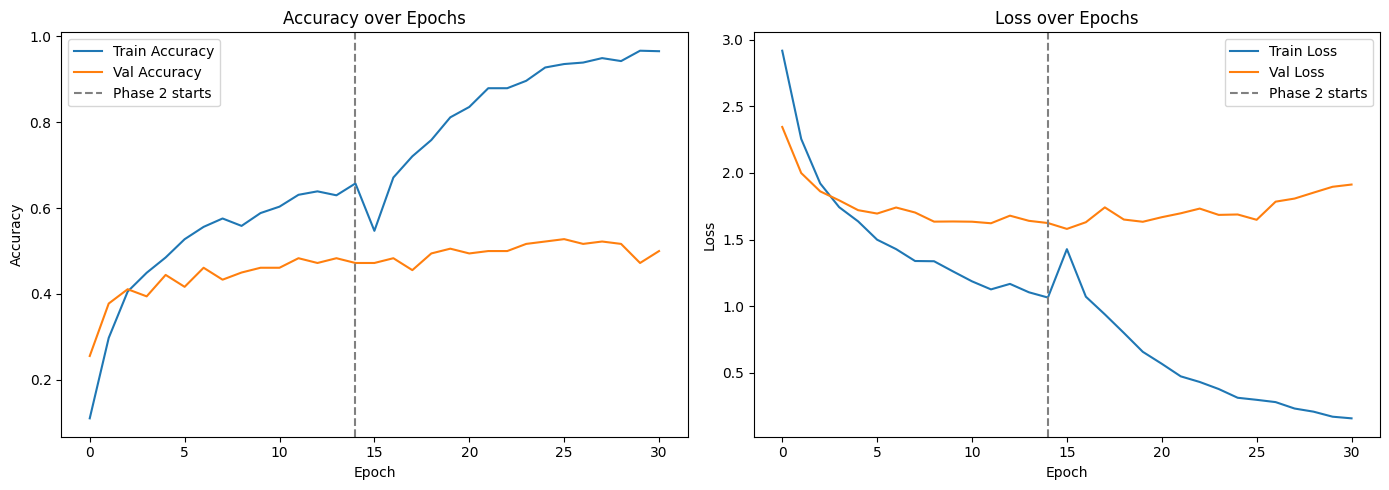

Curves saved to Drive.


In [ ]:
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,     label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=len(history1.history['accuracy'])-1,
            color='gray', linestyle='--', label='Phase 2 starts')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss,     label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history1.history['loss'])-1,
            color='gray', linestyle='--', label='Phase 2 starts')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png')
plt.show()
print("Curves saved to Drive.")

In [ ]:
# Get class names in the correct index order
class_names = [None] * NUM_CLASSES
for name, idx in train_gen.class_indices.items():
    class_names[idx] = name

# Save to Drive
labels_path = '/content/drive/MyDrive/labels.txt'
with open(labels_path, 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print("Labels saved:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Labels saved:
  0: Ahaetulla_prasina
  1: Bungarus_fasciatus
  2: Coelognathus_radiatus
  3: Fowlea_piscator
  4: Laticauda_colubrina
  5: Lycodon_capucinus
  6: Malayopython_reticulatus
  7: Naja_kaouthia
  8: Oligodon_arnensis
  9: Ophiophagus_hannah
  10: Ptyas_mucosa
  11: Python_bivittatus
  12: Rhabdophis_siamensis
  13: Trimeresurus_albolabris


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── CONFIG ─────────────────────────────────────────────────────
IMG_SIZE   = 224
MODEL_PATH = '/content/drive/MyDrive/snake_best_model.keras'
LABELS_PATH = '/content/drive/MyDrive/labels.txt'

# ── LOAD MODEL AND LABELS ──────────────────────────────────────
model = tf.keras.models.load_model(MODEL_PATH)

with open(LABELS_PATH, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

print("Model loaded.")
print(f"Classes: {class_names}")

Model loaded.
Classes: ['Ahaetulla_prasina', 'Bungarus_fasciatus', 'Coelognathus_radiatus', 'Fowlea_piscator', 'Laticauda_colubrina', 'Lycodon_capucinus', 'Malayopython_reticulatus', 'Naja_kaouthia', 'Oligodon_arnensis', 'Ophiophagus_hannah', 'Ptyas_mucosa', 'Python_bivittatus', 'Rhabdophis_siamensis', 'Trimeresurus_albolabris']


In [ ]:
# ── UPLOAD YOUR TEST IMAGE ─────────────────────────────────────
from google.colab import files

uploaded = files.upload()  # pick any snake photo from your computer
test_image_path = list(uploaded.keys())[0]
print(f"Uploaded: {test_image_path}")

Saving 1c86566f-1404-41df-adca-06fc90b86d74.jpg to 1c86566f-1404-41df-adca-06fc90b86d74.jpg
Uploaded: 1c86566f-1404-41df-adca-06fc90b86d74.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/tmp/ipykernel_1518/3235932228.py:33: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


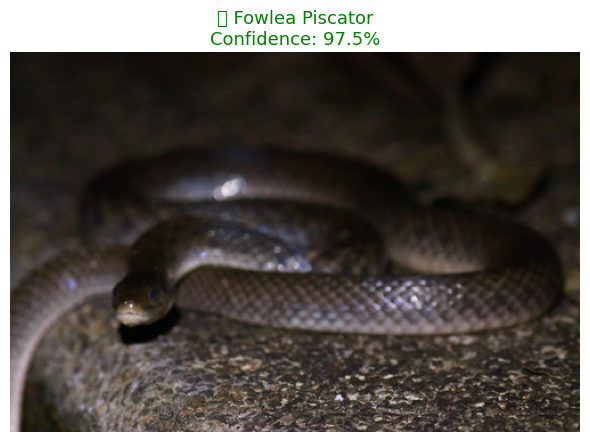


── Top 5 Predictions ──────────────────
  1. Fowlea_piscator                97.5%  █████████████████████████████
  2. Lycodon_capucinus              0.8%  
  3. Malayopython_reticulatus       0.7%  
  4. Rhabdophis_siamensis           0.2%  
  5. Naja_kaouthia                  0.2%  


In [ ]:
# ── PREDICT ────────────────────────────────────────────────────
def predict_snake(img_path, model, class_names, threshold=0.60):

    # Load and preprocess
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0                   # normalize
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension

    # Run prediction
    predictions = model.predict(img_array)
    confidence  = float(np.max(predictions))
    class_idx   = int(np.argmax(predictions))
    species     = class_names[class_idx]

    # Show image
    plt.figure(figsize=(6, 5))
    plt.imshow(mpimg.imread(img_path))
    plt.axis('off')

    if confidence < threshold:
        plt.title(
            f"⚠️ Cannot identify clearly\nConfidence too low: {confidence:.1%}",
            fontsize=13, color='orange'
        )
    else:
        plt.title(
            f"🐍 {species.replace('_', ' ').title()}\n"
            f"Confidence: {confidence:.1%}",
            fontsize=13, color='green'
        )

    plt.tight_layout()
    plt.show()

    # Print top 5 predictions
    print("\n── Top 5 Predictions ──────────────────")
    top5_idx = np.argsort(predictions[0])[::-1][:5]
    for i, idx in enumerate(top5_idx):
        bar = '█' * int(predictions[0][idx] * 30)
        print(f"  {i+1}. {class_names[idx]:<30} {predictions[0][idx]:.1%}  {bar}")

    return species, confidence
species, confidence = predict_snake(test_image_path, model, class_names)

In [ ]:
print("Loading best saved model...")
best_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/snake_best_model.keras'
)

print("Converting to TFLite with quantization...")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save to Drive
tflite_path = '/content/drive/MyDrive/snake_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"\n✅ Done!")
print(f"TFLite model size: {size_mb:.2f} MB")
print(f"Saved to: {tflite_path}")

In [ ]:
from google.colab import files

# Download the two files you need for Flutter
files.download('/content/drive/MyDrive/snake_model.tflite')
files.download('/content/drive/MyDrive/labels.txt')

print("Check your Linux Downloads folder.")